## Chapter 11 of *R for Data Science* (2e, 2023)

In [1]:
from hea import data
from hea.ggplot import plot_annotation, plot_layout, guide_area, theme

mpg = data("mpg", package="ggplot2")

### 11.2

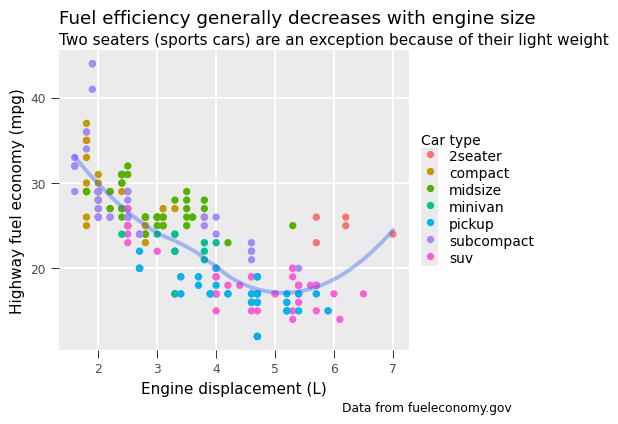

In [2]:
(
    mpg.ggplot(x = "displ", y = "hwy")
        .geom_point(color = "class")
        .geom_smooth(se = False)
        .labs(
            x = "Engine displacement (L)",
            y = "Highway fuel economy (mpg)",
            color = "Car type",
            title = "Fuel efficiency generally decreases with engine size",
            subtitle = "Two seaters (sports cars) are an exception because of their light weight",
            caption = "Data from fueleconomy.gov"
        )
)

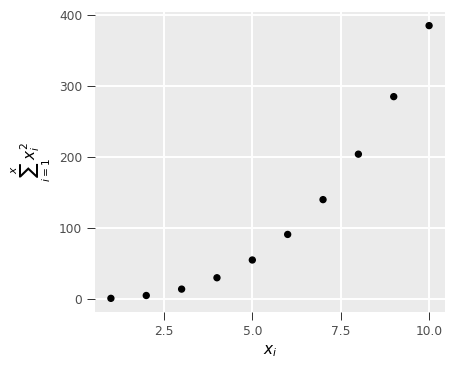

In [3]:
import hea

x = hea.R.seq(1, 10)
y = hea.R.cumsum(x ** 2)
df = hea.from_dict({
        "x": x,
        "y": y,
    })

(
    df
        .ggplot(x="x", y="y")
        .geom_point()
        .labs(
            x = r"$x_i$",
            y = r"$\sum^{x}_{i=1}x^2_i$"
        )
)

### 11.3

In [4]:
from hea import desc, case_when, col

label_info = (
    mpg.arrange(desc("displ"))
       .group_by("drv")
       .slice_head(n=1)
       .mutate(
           drive_type=case_when(
               (col("drv") == "f", "front-wheel drive"),
               (col("drv") == "r", "rear-wheel drive"),
               (col("drv") == "4", "4-wheel drive"),
           )
       )
       .select("displ", "hwy", "drv", "drive_type")
)

# from hea import desc, col, lit, when
# label_info = (
#     mpg.group_by("drv")
#        .slice_max("displ", n=1, with_ties=False)
#        .mutate(
#            drive_type=(
#                when(col("drv") == "f").then(lit("front-wheel drive"))
#                .when(col("drv") == "r").then(lit("rear-wheel drive"))
#                .when(col("drv") == "4").then(lit("4-wheel drive"))
#            ),
#        )
#        .select("displ", "hwy", "drv", "drive_type")
# )


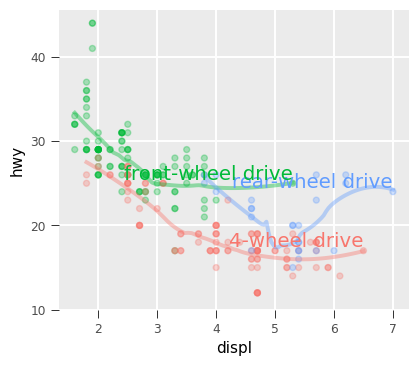

In [5]:
from hea.ggplot import theme

(
    mpg
        .ggplot(x = "displ", y = "hwy", color = "drv")
        .geom_point(alpha = 0.3)
        .geom_smooth(se = False)
        .geom_text(
            data = label_info, 
            x = "displ", y = "hwy", label = "drive_type",
            fontface = "bold", size = 5, hjust = "right", vjust = "bottom"
        ).theme(legend_position = "none")
)

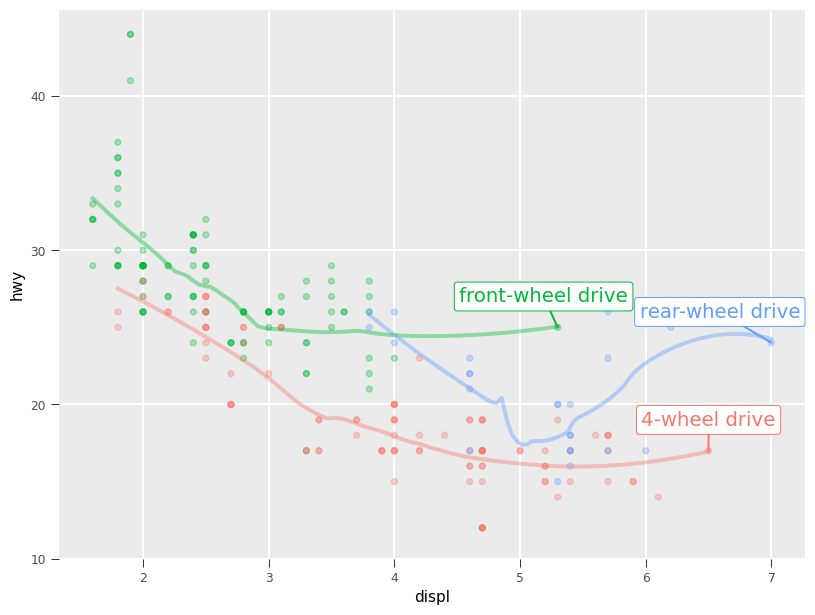

In [6]:
(
    mpg
        .ggplot(x = "displ", y = "hwy", color = "drv")
        .geom_point(alpha = 0.3)
        .geom_smooth(se = False)
        .geom_label_repel(
            data = label_info, 
            x = "displ", y = "hwy", label = "drive_type",
            fontface = "bold", size = 5, nudge_y = 2
        ).theme(legend_position = "none")
).show(figsize=(8,6))

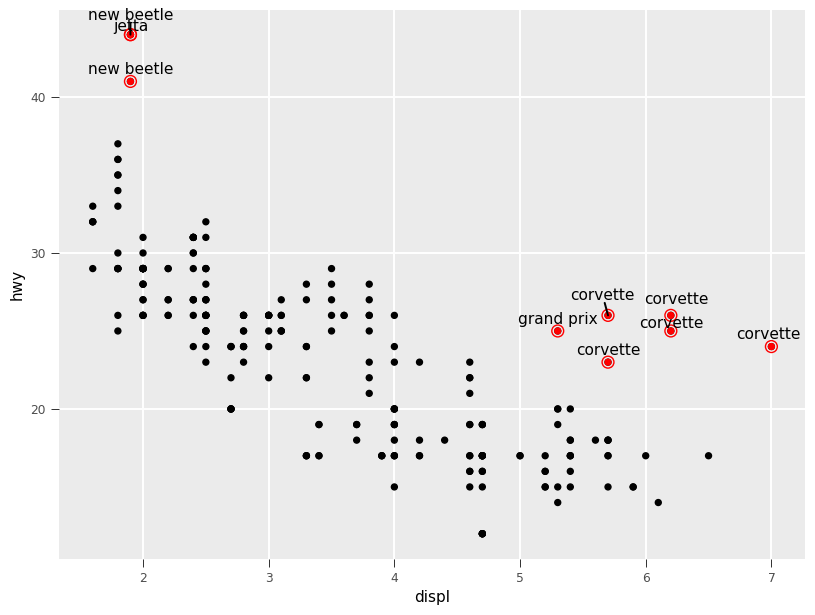

In [7]:
from hea import col
potential_outliers = mpg.filter((col("hwy") > 40) | ((col("hwy") > 20) & (col("displ") > 5)))

(
    mpg
        .ggplot(x = "displ", y = "hwy")
        .geom_point()
        .geom_text_repel(data = potential_outliers, label = "model")
        .geom_point(data = potential_outliers, color = "red")
        .geom_point(
            data = potential_outliers,
            color = "red", size = 3, shape = "circle open"
        )
).show(figsize=(8,6))


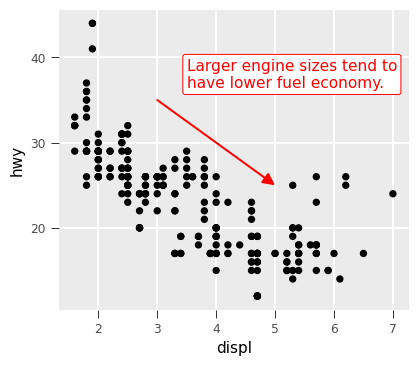

In [8]:
from hea import str_wrap
from hea.ggplot import arrow

trend_text = str_wrap(
    "Larger engine sizes tend\nto have lower fuel economy.", 
    width = 30)

(
    mpg.ggplot(x = "displ", y = "hwy")
        .geom_point()
        .annotate(
            geom = "label", x = 3.5, y = 38,
            label = trend_text,
            hjust = "left", color = "red"
        ).annotate(
            geom = "segment",
            x = 3, y = 35, xend = 5, yend = 25, color = "red",
            arrow = arrow(type = "closed") 
        )
)

### 11.4

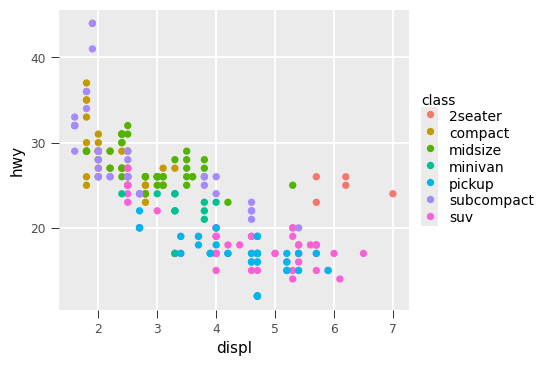

In [9]:
(
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point(color="class")
)

# same as
# (
#     mpg
#         .ggplot(x="displ", y="hwy")
#         .geom_point(color="class")
#         .scale_x_continuous()
#         .scale_y_continuous()
#         .scale_color_discrete()
# )

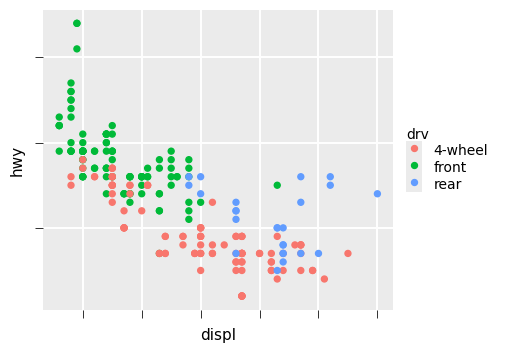

In [10]:
(
    mpg
        .ggplot(x="displ", y="hwy", color="drv")
        .geom_point()
        .scale_x_continuous(labels = None)
        .scale_y_continuous(labels = None)
        .scale_color_discrete(labels = {"4":"4-wheel", "f":"front", "r":"rear"})
)

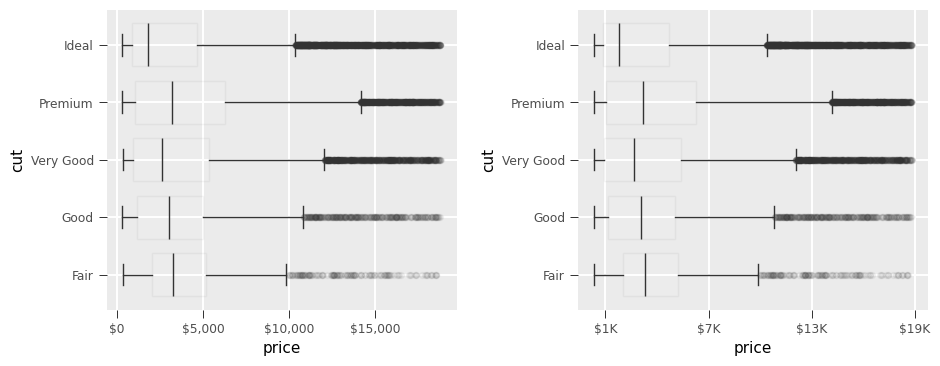

<Figure size 922.5x351 with 0 Axes>

In [11]:
from hea.R import seq
from hea.ggplot import label_dollar

diamonds = data("diamonds")

p1 = (
    diamonds
        .ggplot(x = "price", y = "cut")
        .geom_boxplot(alpha = 0.05)
        .scale_x_continuous(labels = label_dollar())
)
p2 = (
    diamonds
        .ggplot(x = "price", y = "cut")
        .geom_boxplot(alpha = 0.05)   
        .scale_x_continuous(
          labels = label_dollar(scale = 1/1000, suffix = "K"),
          breaks = seq(1000, 19000, by = 6000)
        )
)

p1 | p2
# ggplot(diamonds, aes(x = price, y = cut)) +
#   geom_boxplot(alpha = 0.05) +
#   scale_x_continuous(
#     labels = label_dollar(scale = 1/1000, suffix = "K"), 
#     breaks = seq(1000, 19000, by = 6000)
#   )

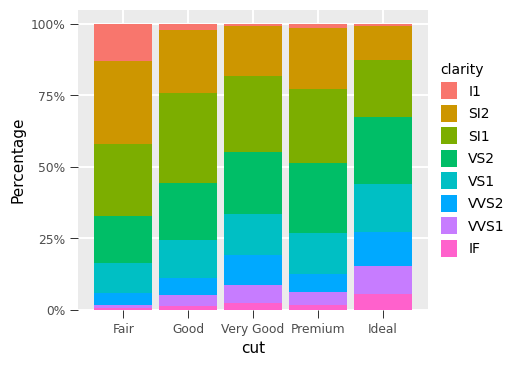

In [12]:
from hea.ggplot import label_percent
(
    diamonds
        .ggplot(x="cut", fill="clarity")
        .geom_bar(position="fill")
        .scale_y_continuous(name="Percentage", labels=label_percent())
)

In [13]:
presidential = data("presidential").mutate(
    start=col("start").str.to_date(), 
    end=col("end").str.to_date()
)

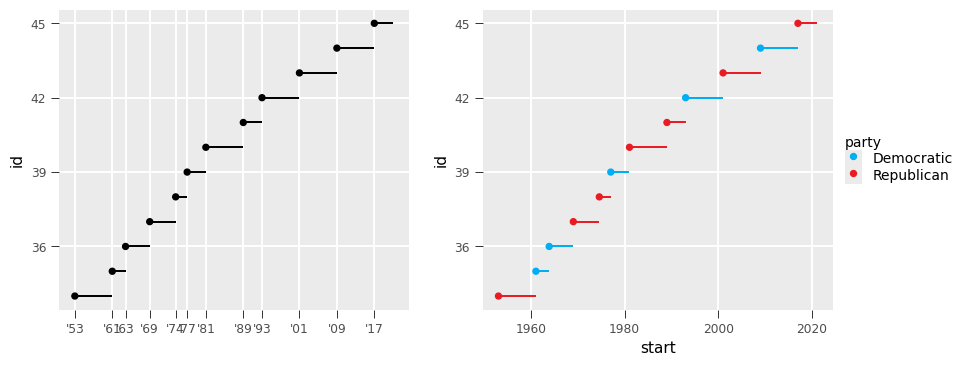

<Figure size 952.125x351 with 0 Axes>

In [14]:
from hea import row_number
p1 = (
    presidential
        .mutate(id = 33 + row_number())
        .ggplot(x = "start", y = "id")
        .geom_point()
        .geom_segment(xend = "end", yend = "id")
        .scale_x_date(name = None, breaks = presidential["start"], date_labels = "'%y")
)

p2 = (
    presidential
        .mutate(id = 33 + row_number())
        .ggplot(x = "start", y = "id", color = "party")
        .geom_point()
        .geom_segment(xend = "end", yend = "id")
        .scale_color_manual(values = {"Republican": "#E81B23", "Democratic": "#00AEF3"})
)

p1 | p2

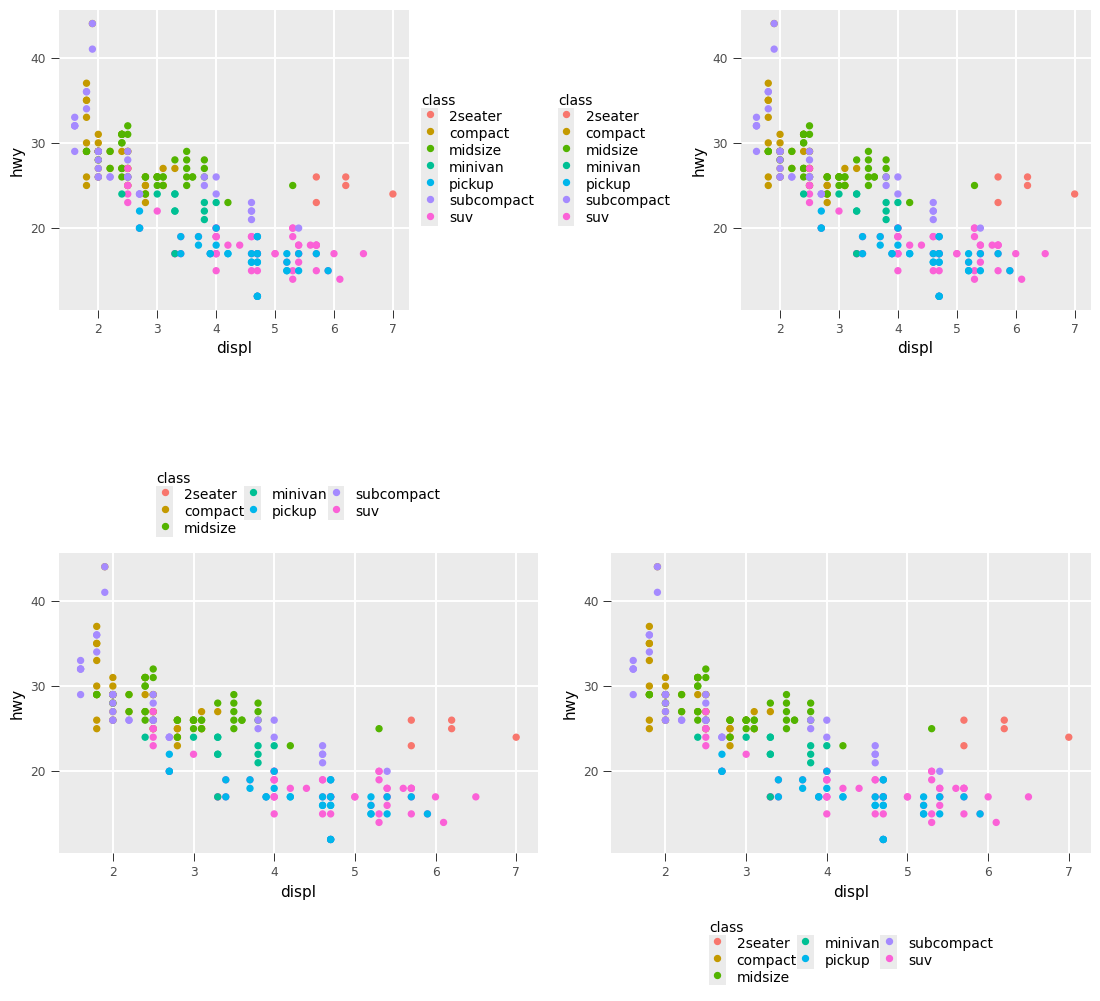

<Figure size 1085.25x1117.4 with 0 Axes>

In [15]:
from hea.ggplot import guides, guide_legend

def base():
    return mpg.ggplot(x="displ", y="hwy").geom_point(color="class")

p1 = base().theme(legend_position="right")
p2 = base().theme(legend_position="left")
p3 = base().theme(legend_position="top")    + guides(color=guide_legend(nrow=3))
p4 = base().theme(legend_position="bottom") + guides(color=guide_legend(nrow=3))

(p1 | p2) / (p3 | p4)

# patchwork whitespace is still bad

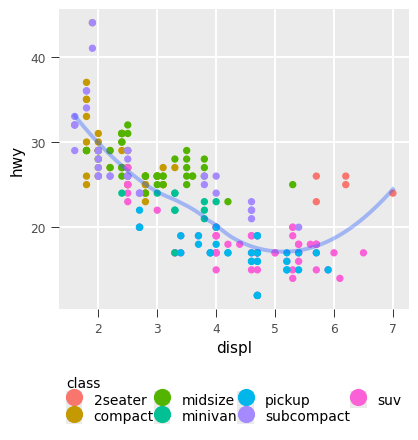

In [16]:
p1 = (
    mpg
        .ggplot(x = "displ", y = "hwy")
        .geom_point(color="class")
        .geom_smooth(se=False)
       .theme(legend_position = "bottom")
        + guides(color = guide_legend(nrow = 2, override_aes = {"size": 4}))
)
p1

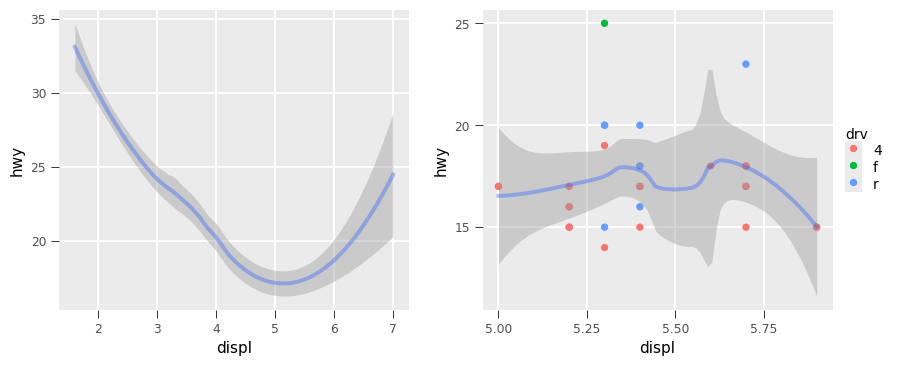

<Figure size 889x351 with 0 Axes>

In [17]:
p1 = (
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_smooth()
)

p2 = (
    mpg
        .filter((col("displ") >= 5) & (col("displ")<6) & (col("hwy") >= 10) & (col("hwy") <=25))
        .ggplot(x = "displ", y = "hwy")
        .geom_point(color="drv")
        .geom_smooth()
)


p1 | p2

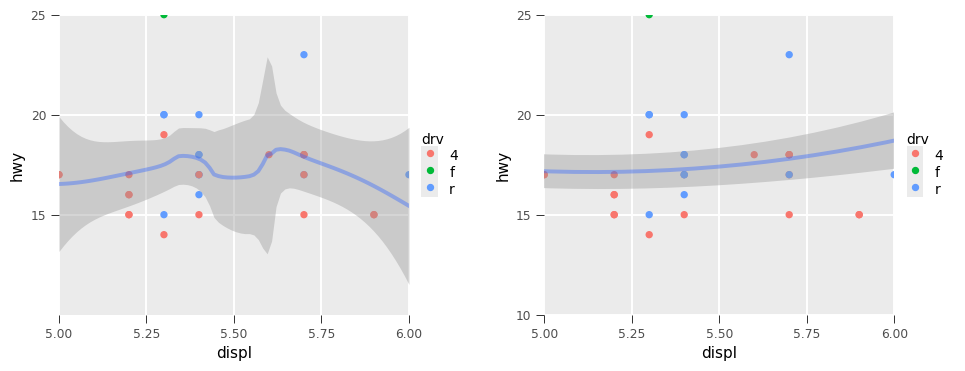

<Figure size 950.625x351 with 0 Axes>

In [18]:
p1 = (
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point(color="drv")
        .geom_smooth()
        .scale_x_continuous(limits=[5,6])
        .scale_y_continuous(limits=[10,25])
)

p2 = (
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point(color="drv")
        .geom_smooth()
        .coord_cartesian(xlim = [5, 6], ylim =[10, 25])
)

p1 | p2

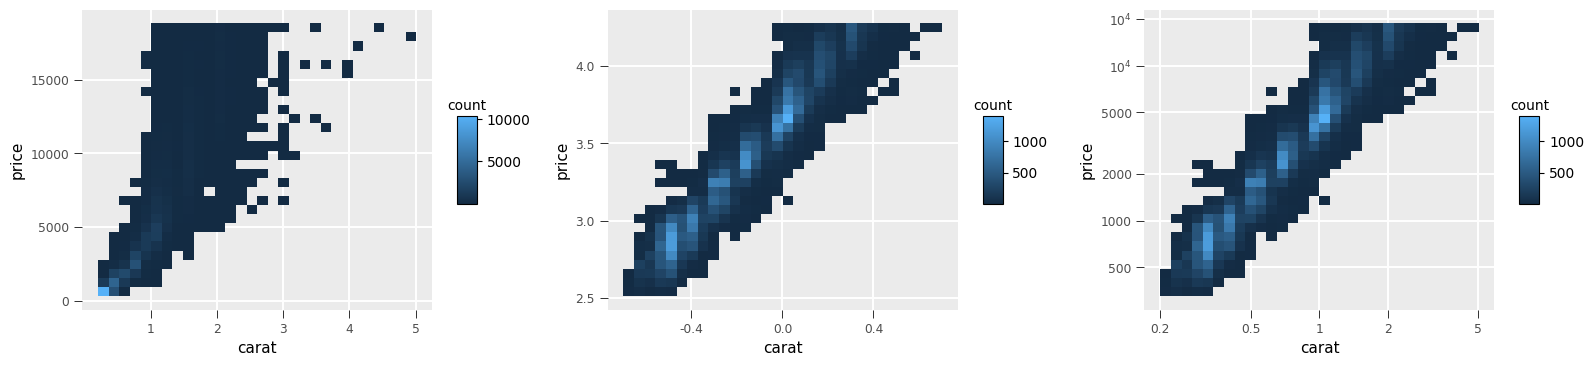

<Figure size 1579.25x351 with 0 Axes>

In [19]:
p1 = (
    diamonds
        .ggplot(x = "carat", y = "price")
        .geom_bin2d()
)

p2 = (
    diamonds
        .ggplot(x = col("carat").log10(), y = col("price").log10())
        .geom_bin2d()
)

p3 = (
    diamonds
        .ggplot(x = "carat", y = "price")
        .geom_bin2d()
        .scale_x_log10()
        .scale_y_log10()    
)

p1 | p2 | p3

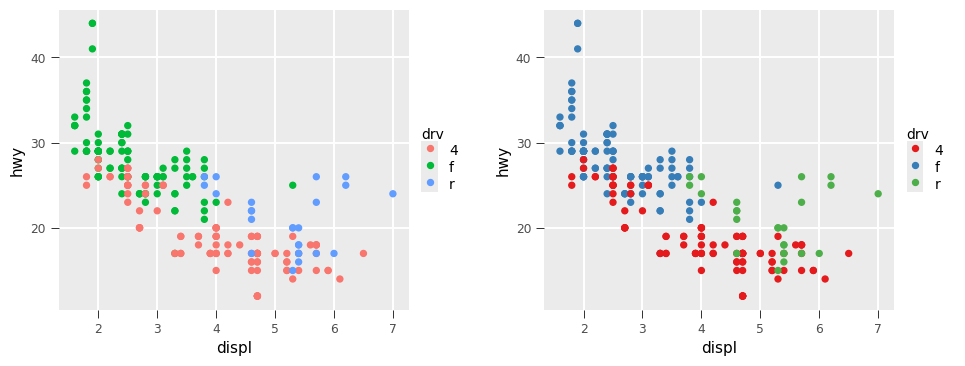

<Figure size 950.5x351 with 0 Axes>

In [20]:
p1 = (
    mpg
        .ggplot(x = "displ", y = "hwy")
        .geom_point(color="drv")
)

p2 = (
    mpg
        .ggplot(x = "displ", y = "hwy")
        .geom_point(color="drv")
        .scale_color_brewer(palette = "Set1")
)

p1 | p2

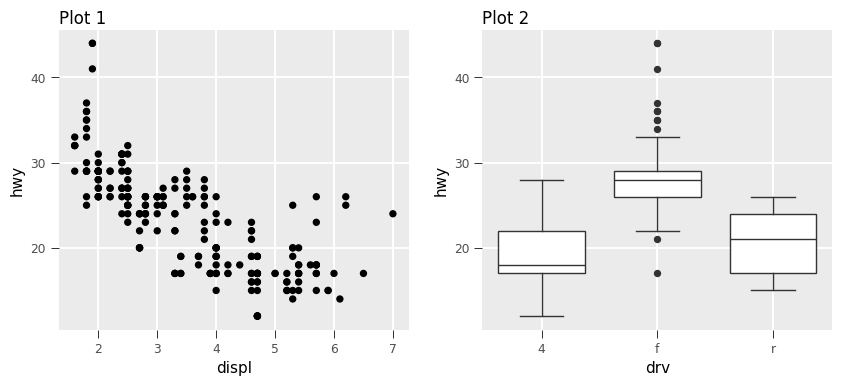

<Figure size 827x373 with 0 Axes>

In [21]:
p1 = mpg.ggplot(x = "displ", y = "hwy").geom_point().labs(title = "Plot 1")
p2 = mpg.ggplot(x = "drv", y = "hwy").geom_boxplot().labs(title = "Plot 2")
p3 = mpg.ggplot(x = "cty", y = "hwy").geom_point().labs(title = "Plot 3")

p1 + p2

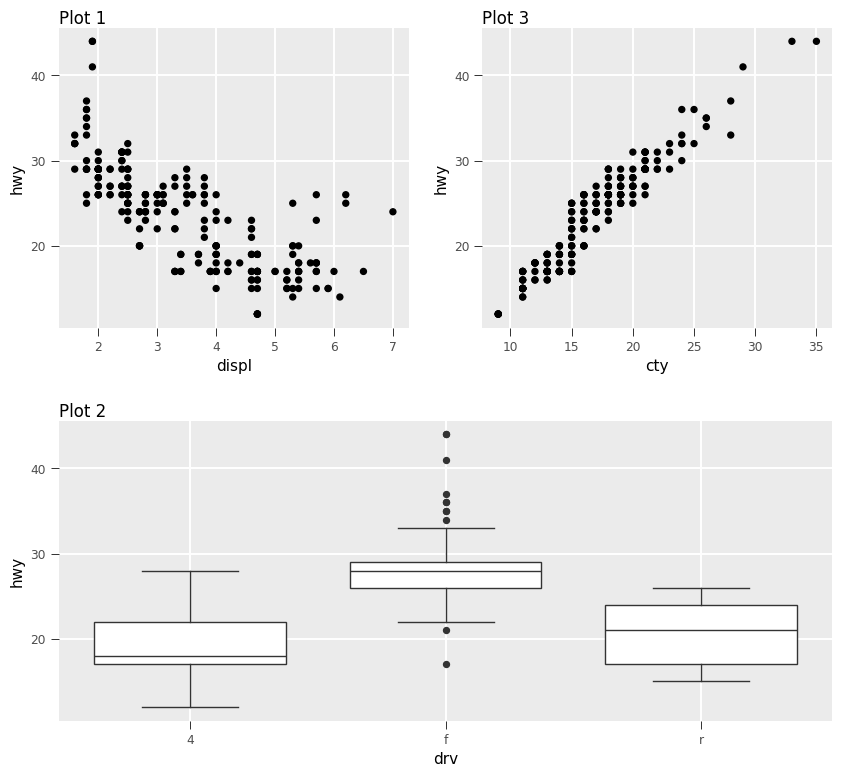

<Figure size 827x766 with 0 Axes>

In [22]:
(p1 + p3) / p2

<Figure size 800x800 with 0 Axes>

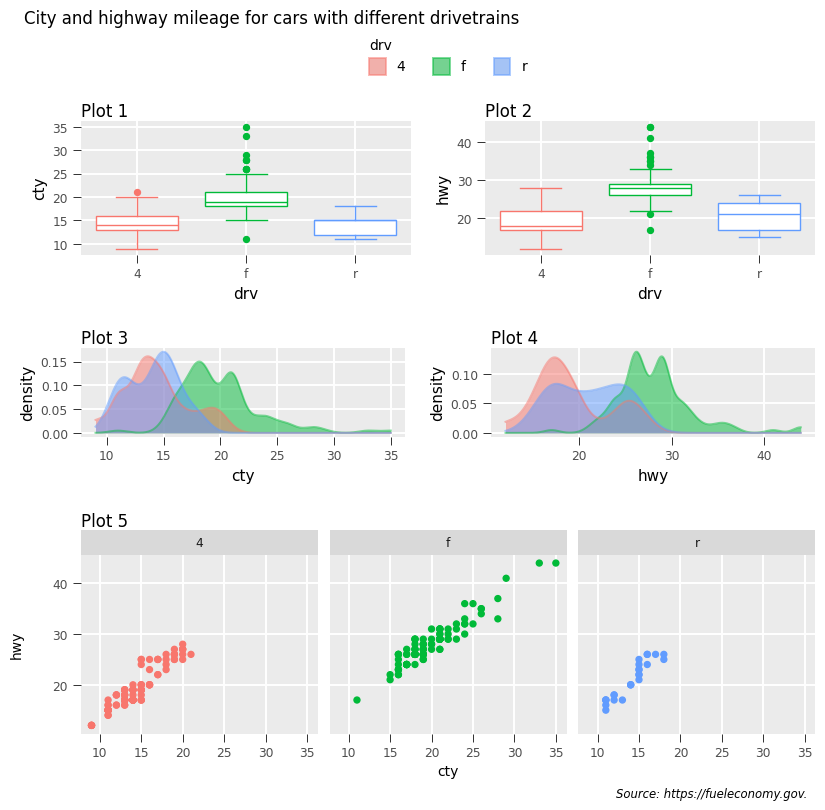

In [23]:

p1 = mpg.ggplot(x = "drv", y = "cty", color = "drv").geom_boxplot(show_legend = False).labs(title = "Plot 1")
p2 = mpg.ggplot(x = "drv", y = "hwy", color = "drv").geom_boxplot(show_legend = False).labs(title = "Plot 2")
p3 = mpg.ggplot(x = "cty", color = "drv", fill = "drv").geom_density(alpha = 0.5).labs(title = "Plot 3")
p4 = mpg.ggplot(x = "hwy", color = "drv", fill = "drv").geom_density(alpha = 0.5).labs(title = "Plot 4")
p5 = mpg.ggplot(x = "cty", y = "hwy", color = "drv").geom_point(show_legend = False).facet_wrap("~drv").labs(title = "Plot 5")

p = (guide_area() / (p1 +p2) / (p3 + p4) / p5) + plot_annotation(
    title = "City and highway mileage for cars with different drivetrains",
    caption = "Source: https://fueleconomy.gov."
) + plot_layout(
    guides = "collect",
    heights = [1, 3, 2, 4],
) & theme(legend_position = "top")
p.show(figsize=(8, 8))